<a href="https://colab.research.google.com/github/Eunsuk2/wed_2026_bigdatacomputing/blob/main/20211582_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ 환경 설정 및 한글 폰트 로드 완료

 Merge 데이터 샘플
            평균기온  최대풍속  평균풍속  7day_avg  month  year season  평균기온_scaled  \
일시                                                                        
2010-08-01  28.7   8.3   3.4       NaN      8  2010     여름     0.935484   
2010-08-02  25.2   8.7   3.8       NaN      8  2010     여름     0.848635   
2010-08-03  22.1   6.3   2.9       NaN      8  2010     여름     0.771712   
2010-08-04  25.3   6.6   4.2       NaN      8  2010     여름     0.851117   
2010-08-05  27.2   9.1   5.6       NaN      8  2010     여름     0.898263   

            평균풍속_scaled  rain_flag  
일시                                  
2010-08-01     0.217687          1  
2010-08-02     0.244898          1  
2010-08-03     0.183673          1  
2010-08-04     0.272109          1  
2010-08-05     0.367347          1  

 계절별 통계
        count       mean       std   min     25%   50%   75%   max
season                                                            
가을      910.0  15.201099  5.149311 

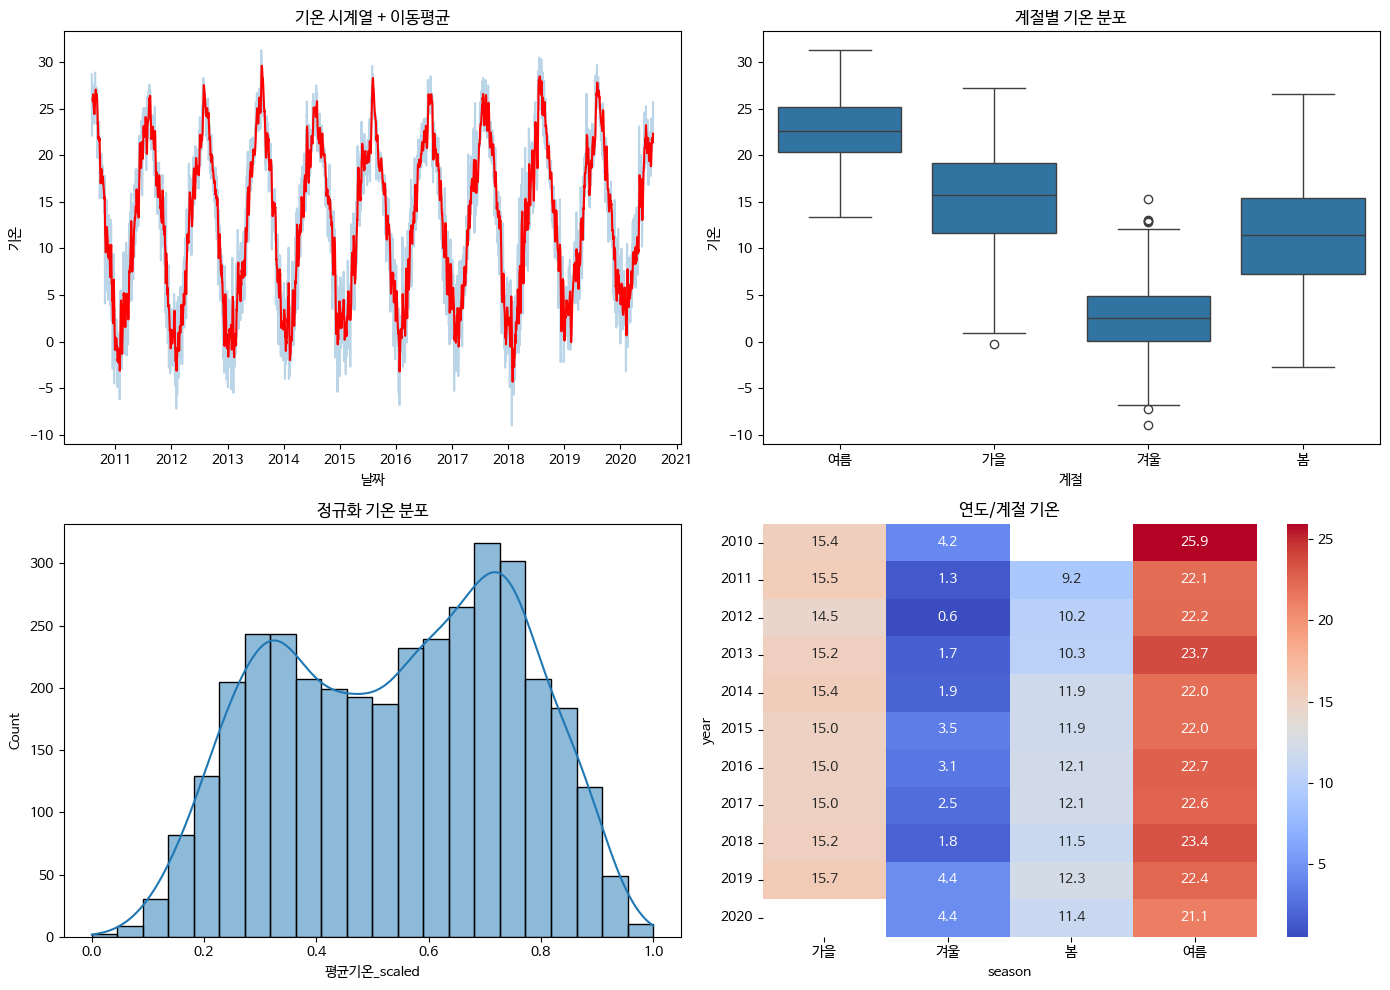

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

# 데이터 로드
path = 'https://github.com/dongupak/DataML/raw/main/csv/'
weather = pd.read_csv(path + 'weather.csv', index_col=0, encoding='CP949')

# ---------------------------------------------------------
# 2. 전처리
# ---------------------------------------------------------
def preprocess_data(df):
    df.index = pd.to_datetime(df.index)
    df = df.fillna(method='ffill')
    return df

# ---------------------------------------------------------
# 3. Min-Max 정규화
# ---------------------------------------------------------
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# ---------------------------------------------------------
# 4. 특징 생성
# ---------------------------------------------------------
def create_features(df):
    df['7day_avg'] = df['평균기온'].rolling(7).mean()
    df['month'] = df.index.month
    df['year'] = df.index.year

    def get_season(month):
        if month in [3,4,5]: return '봄'
        elif month in [6,7,8]: return '여름'
        elif month in [9,10,11]: return '가을'
        else: return '겨울'

    df['season'] = df['month'].apply(get_season)

    df['평균기온_scaled'] = min_max_scale(df['평균기온'])
    df['평균풍속_scaled'] = min_max_scale(df['평균풍속'])

    return df

# ---------------------------------------------------------
# 5. concat + merge
# ---------------------------------------------------------
def combine_data(df):
    df_copy = df.copy()
    df_copy['평균기온'] += 2

    concat_df = pd.concat([df, df_copy])

    extra = pd.DataFrame({
        'date': df.index,
        'rain_flag': np.where(df['평균풍속'] > 0, 1, 0)
    }).set_index('date')

    merge_df = pd.merge(df, extra, left_index=True, right_index=True)

    return concat_df, merge_df

# ---------------------------------------------------------
# 6. 분석
# ---------------------------------------------------------
def analyze_data(df):
    seasonal_stats = df.groupby('season')['평균기온'].describe()

    pivot = df.pivot_table(
        values='평균기온',
        index='year',
        columns='season',
        aggfunc='mean'
    )

    print("\n 계절별 통계")
    print(seasonal_stats)

    print("\n 연도/계절 피벗")
    print(pivot)

    return seasonal_stats, pivot

# ---------------------------------------------------------
# 7. 시각화
# ---------------------------------------------------------
def visualize(df, pivot):
    plt.figure(figsize=(14,10))

    plt.subplot(2,2,1)
    plt.plot(df.index, df['평균기온'], alpha=0.3)
    plt.plot(df.index, df['7day_avg'], color='red')
    plt.title('기온 시계열 + 이동평균')
    plt.xlabel('날짜')
    plt.ylabel('기온')

    plt.subplot(2,2,2)
    sns.boxplot(x='season', y='평균기온', data=df)
    plt.title('계절별 기온 분포')
    plt.xlabel('계절')
    plt.ylabel('기온')

    plt.subplot(2,2,3)
    sns.histplot(df['평균기온_scaled'], kde=True)
    plt.title('정규화 기온 분포')

    plt.subplot(2,2,4)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm')
    plt.title('연도/계절 기온')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 8. 엑셀 저장
# ---------------------------------------------------------
def save_to_excel(df, seasonal_stats, pivot, merge_df, concat_df):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='preprocessed')
        seasonal_stats.to_excel(writer, sheet_name='season_stats')
        pivot.to_excel(writer, sheet_name='pivot_table')

        merge_df.to_excel(writer, sheet_name='merged_data')
        concat_df.to_excel(writer, sheet_name='concat_data')

# ---------------------------------------------------------
# 9. 실행
# ---------------------------------------------------------
weather = preprocess_data(weather)
weather = create_features(weather)

concat_df, merge_df = combine_data(weather)

print("\n Merge 데이터 샘플")
print(merge_df.head())

seasonal_stats, pivot = analyze_data(weather)

visualize(weather, pivot)
save_to_excel(weather, seasonal_stats, pivot, merge_df, concat_df)